DATASET SHAPE
Rows: 1000
Columns: 24

FIRST 5 ROWS


,Transaction ID,Date,Gender,Age,Age Group,Product Category,Quantity,Price per Unit,Total Amount,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Min_age,Max_age,Avg_age,Total Sales Revenue,Average Order value,Category,Sales
0,1,11/24/2023,Male,34,Middle Age,Beauty,3,50,150,NaN,...,NaN,NaN,NaN,18.0,64.0,41.0,456000.0,456.0,Electronics,156905.0
1,2,2/27/2023,Female,26,Adolescent,Clothing,2,500,1000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clothing,155580.0
2,3,1/13/2023,Male,50,Middle Age,Electronics,1,30,30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Beauty,143515.0
3,4,5/21/2023,Male,37,Middle Age,Clothing,1,500,500,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,5/6/2023,Male,30,Adolescent,Beauty,2,50,100,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



COLUMN DATA TYPES


,0
Transaction ID,int64
Date,object
Gender,object
Age,int64
Age Group,object
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64
Unnamed: 9,float64



MISSING VALUES


,0
Transaction ID,0
Date,0
Gender,0
Age,0
Age Group,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0
Unnamed: 9,1000



DUPLICATE ROWS: 0
Shape after removing duplicates: (1000, 24)

DESCRIPTIVE STATISTICS


,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


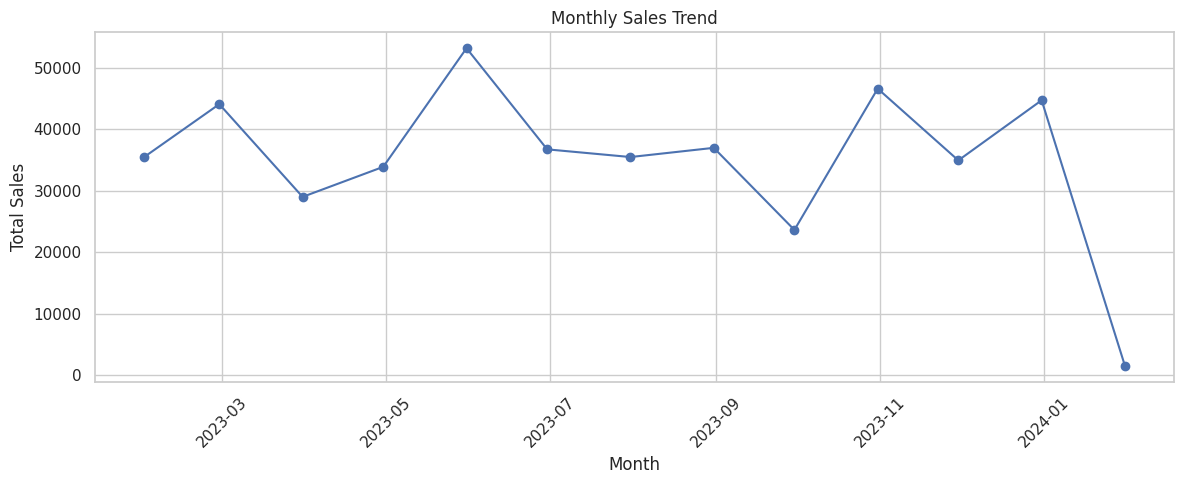

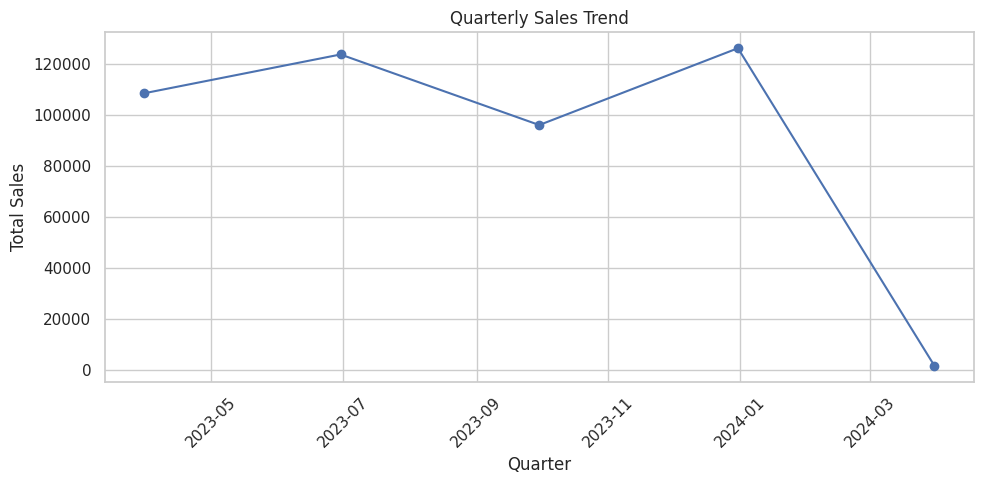

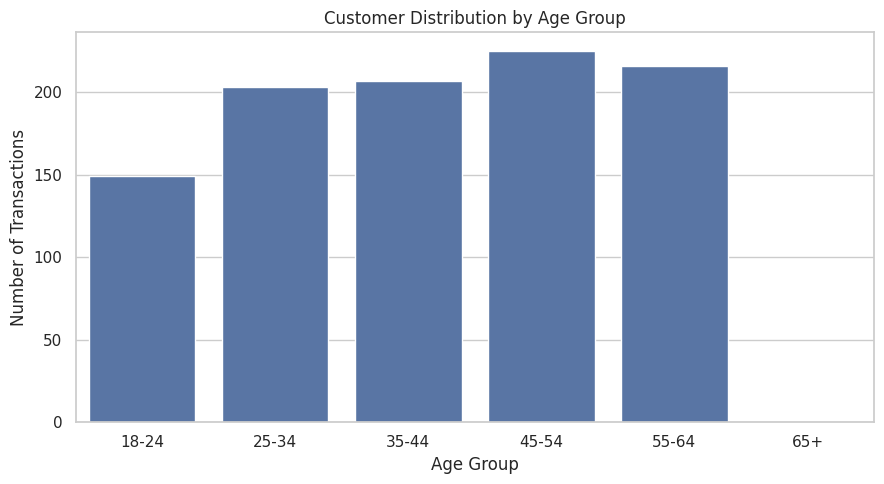

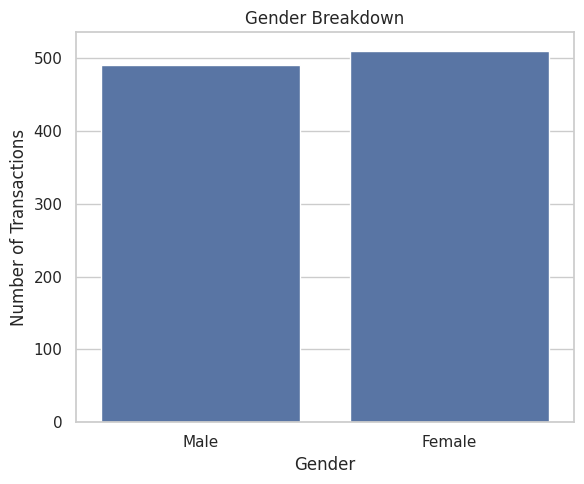

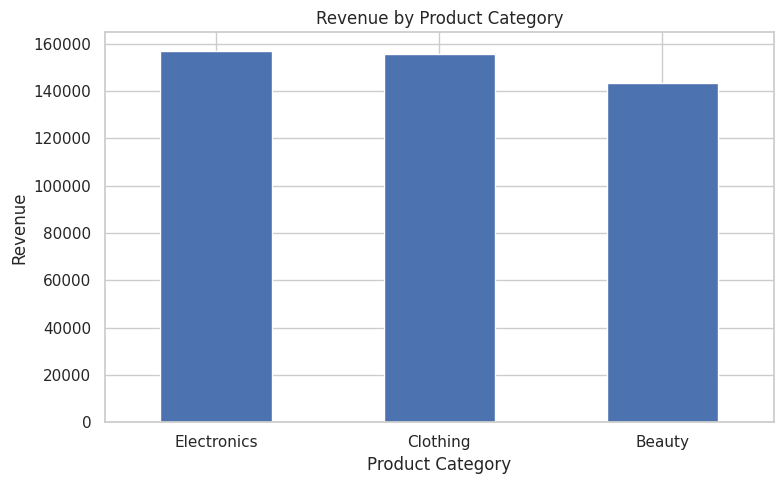


REVENUE BY CATEGORY


,Revenue
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515



TOP 10 PRODUCT PROXIES


,Units_Sold,Revenue
Product Proxy,,
Clothing | ₹300,193,57900
Clothing | ₹50,189,9450
Clothing | ₹25,184,4600
Electronics | ₹300,183,54900
Electronics | ₹25,181,4525
Electronics | ₹50,175,8750
Clothing | ₹30,171,5130
Beauty | ₹50,170,8500
Electronics | ₹500,169,84500


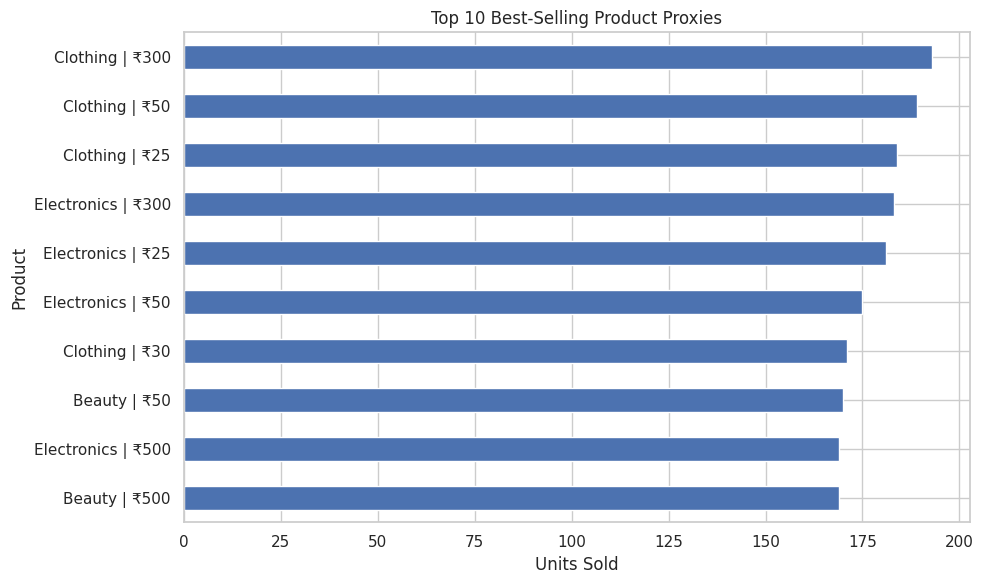

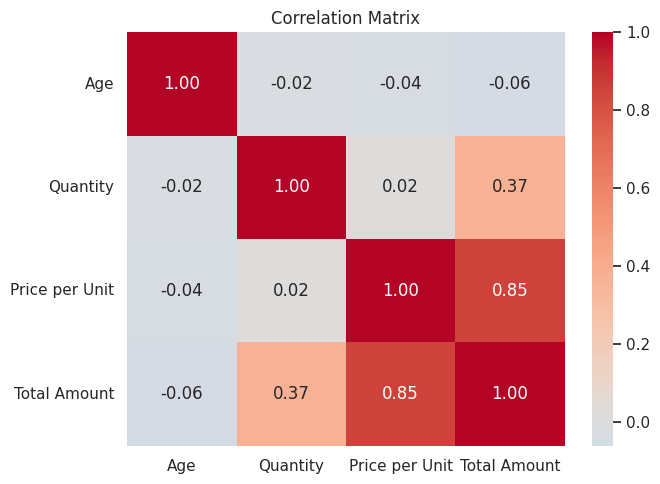

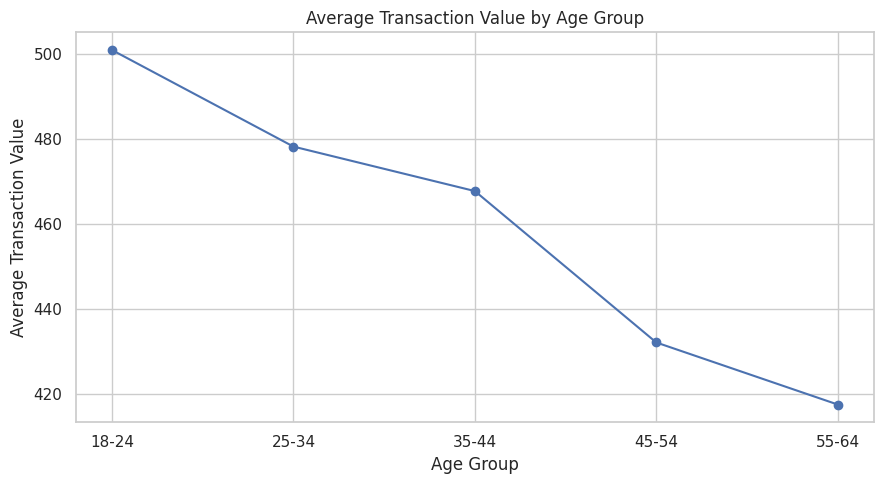

,Average Transaction Value
Age Group,
18-24,501.006711
25-34,478.275862
35-44,467.801932
45-54,432.155556
55-64,417.546296
65+,NaN



================ KEY FINDINGS ================
Highest monthly sales: May 2023 with ₹53,150.00
Highest quarterly sales: 2023-12-31 00:00:00 with ₹126,190.00
Highest revenue category: Electronics with ₹156,905.00
Highest average transaction age group: 18-24 with ₹501.01

================ CONCLUSION ================

1. Sales trends can be used to plan inventory and promotions
   around high-performing months and quarters.

2. The highest-revenue product category should receive
   stronger promotional visibility and inventory planning.

3. Customer age-group spending patterns can be used to create
   targeted marketing campaigns and personalised offers.

4. The correlation analysis helps identify relationships
   between transaction variables.

5. Product-level analysis is limited because the dataset does
   not contain actual Product Name/SKU information. A real
   product-level ranking would require SKU/product-name data.



In [1]:
# ============================================================
# OIBSIP - DATA ANALYTICS
# TASK 1: EDA ON RETAIL SALES DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("Retail Sales Data Set.csv")

print("DATASET SHAPE")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFIRST 5 ROWS")
display(df.head())

print("\nCOLUMN DATA TYPES")
display(df.dtypes)

print("\nMISSING VALUES")
display(df.isnull().sum())


# ------------------------------------------------------------
# 2. DATA CLEANING / PREPARATION
# ------------------------------------------------------------

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Gender"] = df["Gender"].astype(str).str.strip().str.title()
df["Product Category"] = (
    df["Product Category"].astype(str).str.strip().str.title()
)

print("\nDUPLICATE ROWS:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


# ------------------------------------------------------------
# 3. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

numeric_columns = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

print("\nDESCRIPTIVE STATISTICS")
display(statistics)


# ------------------------------------------------------------
# 4. MONTHLY SALES TREND
# ------------------------------------------------------------

monthly_sales = (
    df.set_index("Date")
      .resample("ME")["Total Amount"]
      .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. QUARTERLY SALES TREND
# ------------------------------------------------------------

quarterly_sales = (
    df.set_index("Date")
      .resample("QE")["Total Amount"]
      .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. CUSTOMER AGE GROUP ANALYSIS
# ------------------------------------------------------------

bins = [17, 24, 34, 44, 54, 64, 100]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Age Group",
    order=labels
)
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. GENDER BREAKDOWN
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Gender")
plt.title("Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. REVENUE BY PRODUCT CATEGORY
# ------------------------------------------------------------

category_revenue = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nREVENUE BY CATEGORY")
display(category_revenue.to_frame("Revenue"))


# ------------------------------------------------------------
# 9. TOP 10 BEST-SELLING PRODUCT PROXIES
# ------------------------------------------------------------
# NOTE:
# The selected dataset does not contain a Product Name/SKU column.
# Therefore, Product Category + Price per Unit is used as a
# documented proxy instead of pretending product names exist.

df["Product Proxy"] = (
    df["Product Category"].astype(str)
    + " | ₹"
    + df["Price per Unit"].round(0).astype(int).astype(str)
)

top_products = (
    df.groupby("Product Proxy")
      .agg(
          Units_Sold=("Quantity", "sum"),
          Revenue=("Total Amount", "sum")
      )
      .sort_values("Units_Sold", ascending=False)
      .head(10)
)

print("\nTOP 10 PRODUCT PROXIES")
display(top_products)

plt.figure(figsize=(10, 6))
top_products["Units_Sold"].sort_values().plot(kind="barh")
plt.title("Top 10 Best-Selling Product Proxies")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. CORRELATION HEATMAP
# ------------------------------------------------------------

correlation = df[
    ["Age", "Quantity", "Price per Unit", "Total Amount"]
].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. ADDITIONAL VISUALISATION
# Average Transaction Value by Age Group
# ------------------------------------------------------------

average_by_age = (
    df.groupby("Age Group", observed=True)["Total Amount"]
      .mean()
      .reindex(labels)
)

plt.figure(figsize=(9, 5))
plt.plot(
    average_by_age.index,
    average_by_age.values,
    marker="o"
)
plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Value")
plt.tight_layout()
plt.show()

display(
    average_by_age.to_frame("Average Transaction Value")
)


# ------------------------------------------------------------
# 12. KEY FINDINGS
# ------------------------------------------------------------

highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

highest_quarter = quarterly_sales.idxmax()
highest_quarter_sales = quarterly_sales.max()

highest_category = category_revenue.idxmax()
highest_category_revenue = category_revenue.max()

highest_age_group = average_by_age.idxmax()
highest_age_value = average_by_age.max()

print("\n================ KEY FINDINGS ================")

print(
    f"Highest monthly sales: "
    f"{highest_month.strftime('%B %Y')} "
    f"with ₹{highest_month_sales:,.2f}"
)

print(
    f"Highest quarterly sales: "
    f"{highest_quarter} "
    f"with ₹{highest_quarter_sales:,.2f}"
)

print(
    f"Highest revenue category: "
    f"{highest_category} "
    f"with ₹{highest_category_revenue:,.2f}"
)

print(
    f"Highest average transaction age group: "
    f"{highest_age_group} "
    f"with ₹{highest_age_value:,.2f}"
)


# ------------------------------------------------------------
# 13. FINAL SUMMARY
# ------------------------------------------------------------

print("""
================ CONCLUSION ================

1. Sales trends can be used to plan inventory and promotions
   around high-performing months and quarters.

2. The highest-revenue product category should receive
   stronger promotional visibility and inventory planning.

3. Customer age-group spending patterns can be used to create
   targeted marketing campaigns and personalised offers.

4. The correlation analysis helps identify relationships
   between transaction variables.

5. Product-level analysis is limited because the dataset does
   not contain actual Product Name/SKU information. A real
   product-level ranking would require SKU/product-name data.
""")